# Task 2: Hierarchical Clustering — Wholesale Customer Segmentation

**Dataset:** Wholesale customers (`Wholesale customers data.csv`)  
**Goal:** Segment wholesale customers using Agglomerative Hierarchical Clustering, use dendrograms to determine the optimal number of clusters, compare linkage methods, visualise results, and derive business insights.

---
## Section 1 — Data Loading & Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('datasets/Wholesale customers data.csv')

print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

Shape: (440, 8)

Column dtypes:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
delicatessen        int64
dtype: object

Null counts:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
delicatessen        0
dtype: int64


In [3]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,delicatessen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [4]:
df.describe().round(2)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,delicatessen
count,440.00,440.00,440.00,440.00,440.00,440.00,440.00,440.00
mean,1.32,2.54,12000.30,5796.27,7951.28,3071.93,2881.49,1524.87
std,0.47,0.77,12647.33,7380.38,9503.16,4854.67,4767.85,2820.11
min,1.00,1.00,3.00,55.00,3.00,25.00,3.00,3.00
25%,1.00,2.00,3127.75,1533.00,2153.00,742.25,256.75,408.25
50%,1.00,3.00,8504.00,3627.00,4755.50,1526.00,816.50,965.50
75%,2.00,3.00,16933.75,7190.25,10655.75,3554.25,3922.00,1820.25
max,2.00,3.00,112151.00,73498.00,92780.00,60869.00,40827.00,47943.00


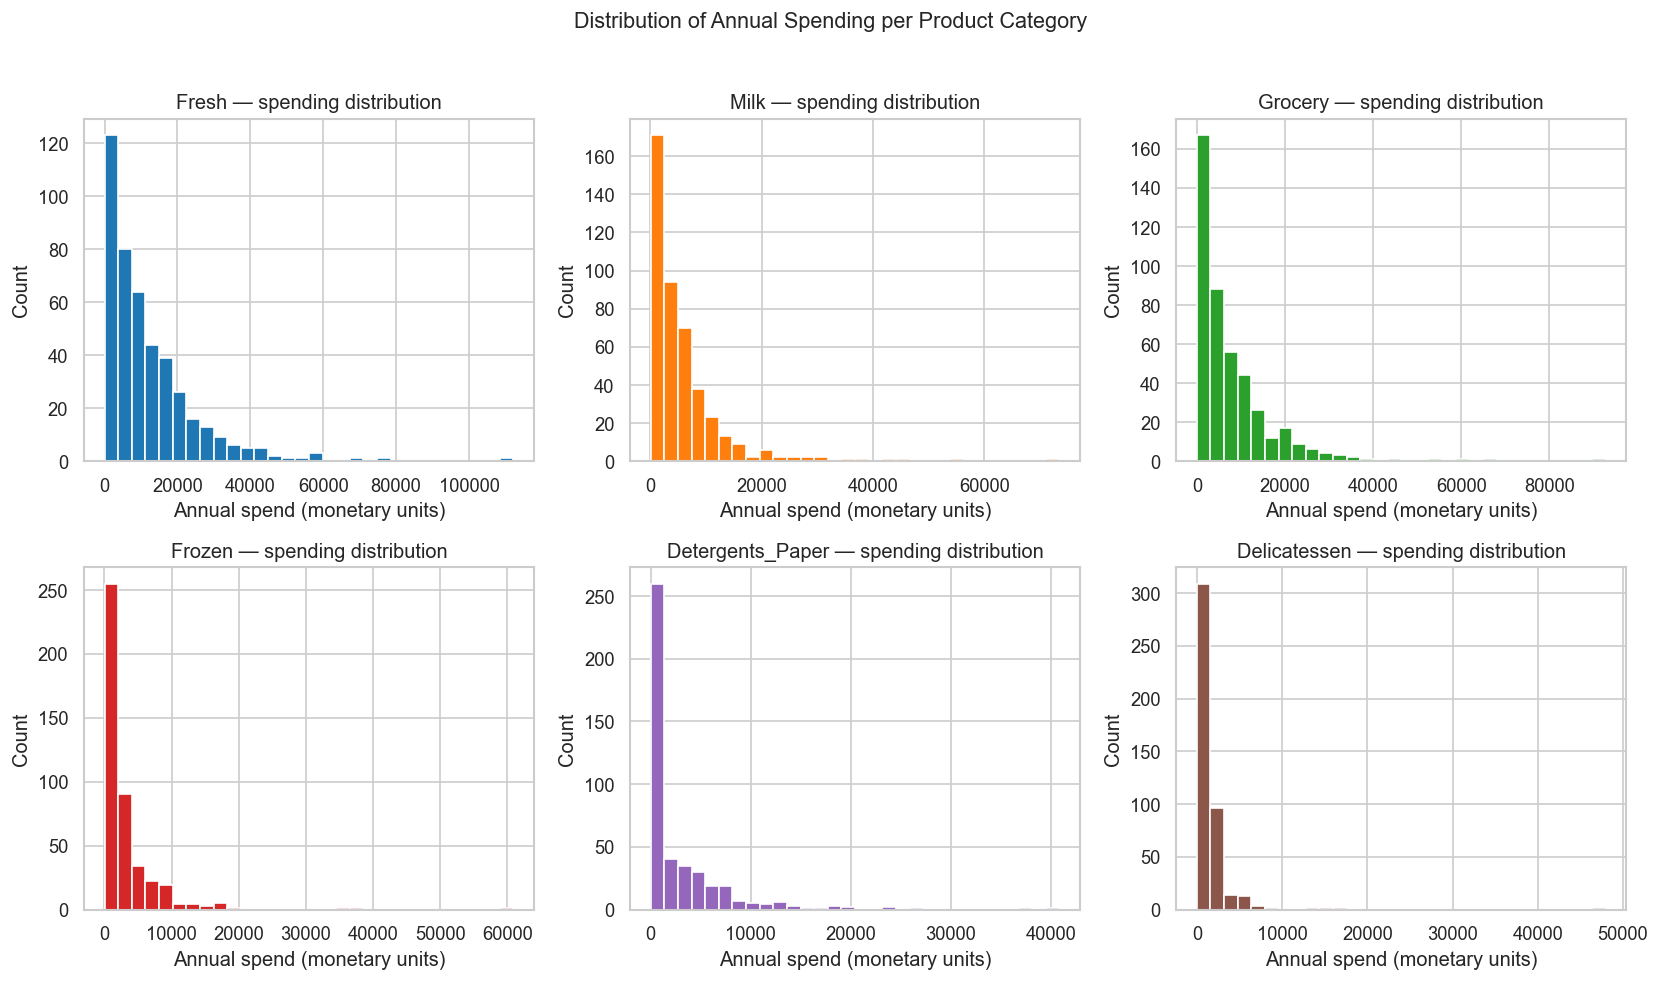

In [5]:
# Rename column for consistency
df.rename(columns={'delicatessen': 'Delicatessen'}, inplace=True)

SPENDING_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(SPENDING_COLS):
    axes[i].hist(df[col], bins=30, edgecolor='white', color=sns.color_palette('tab10')[i])
    axes[i].set_title(f'{col} — spending distribution')
    axes[i].set_xlabel('Annual spend (monetary units)')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Annual Spending per Product Category', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

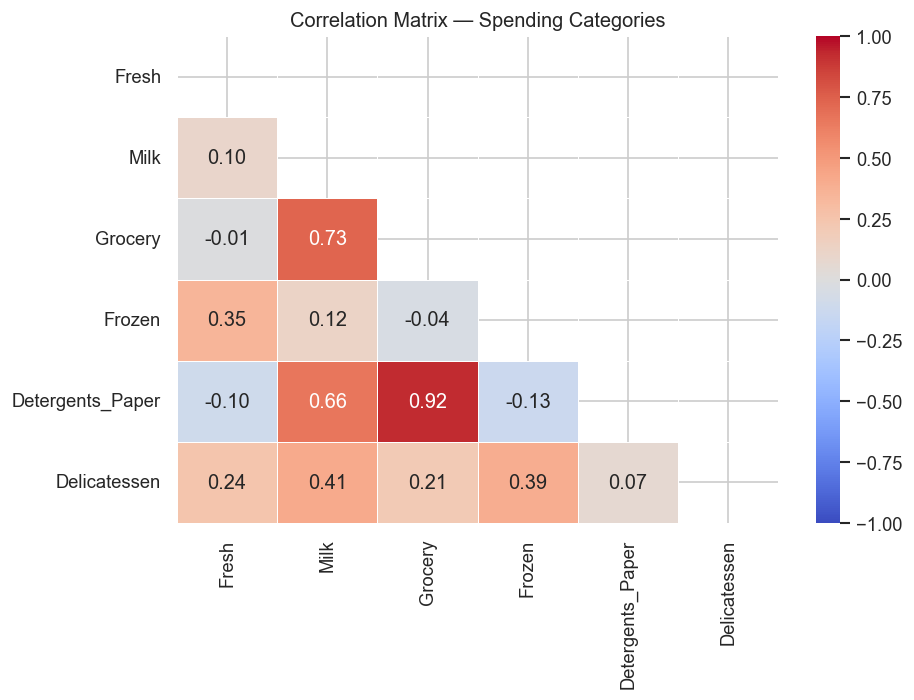

In [6]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[SPENDING_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Spending Categories')
plt.tight_layout()
plt.show()

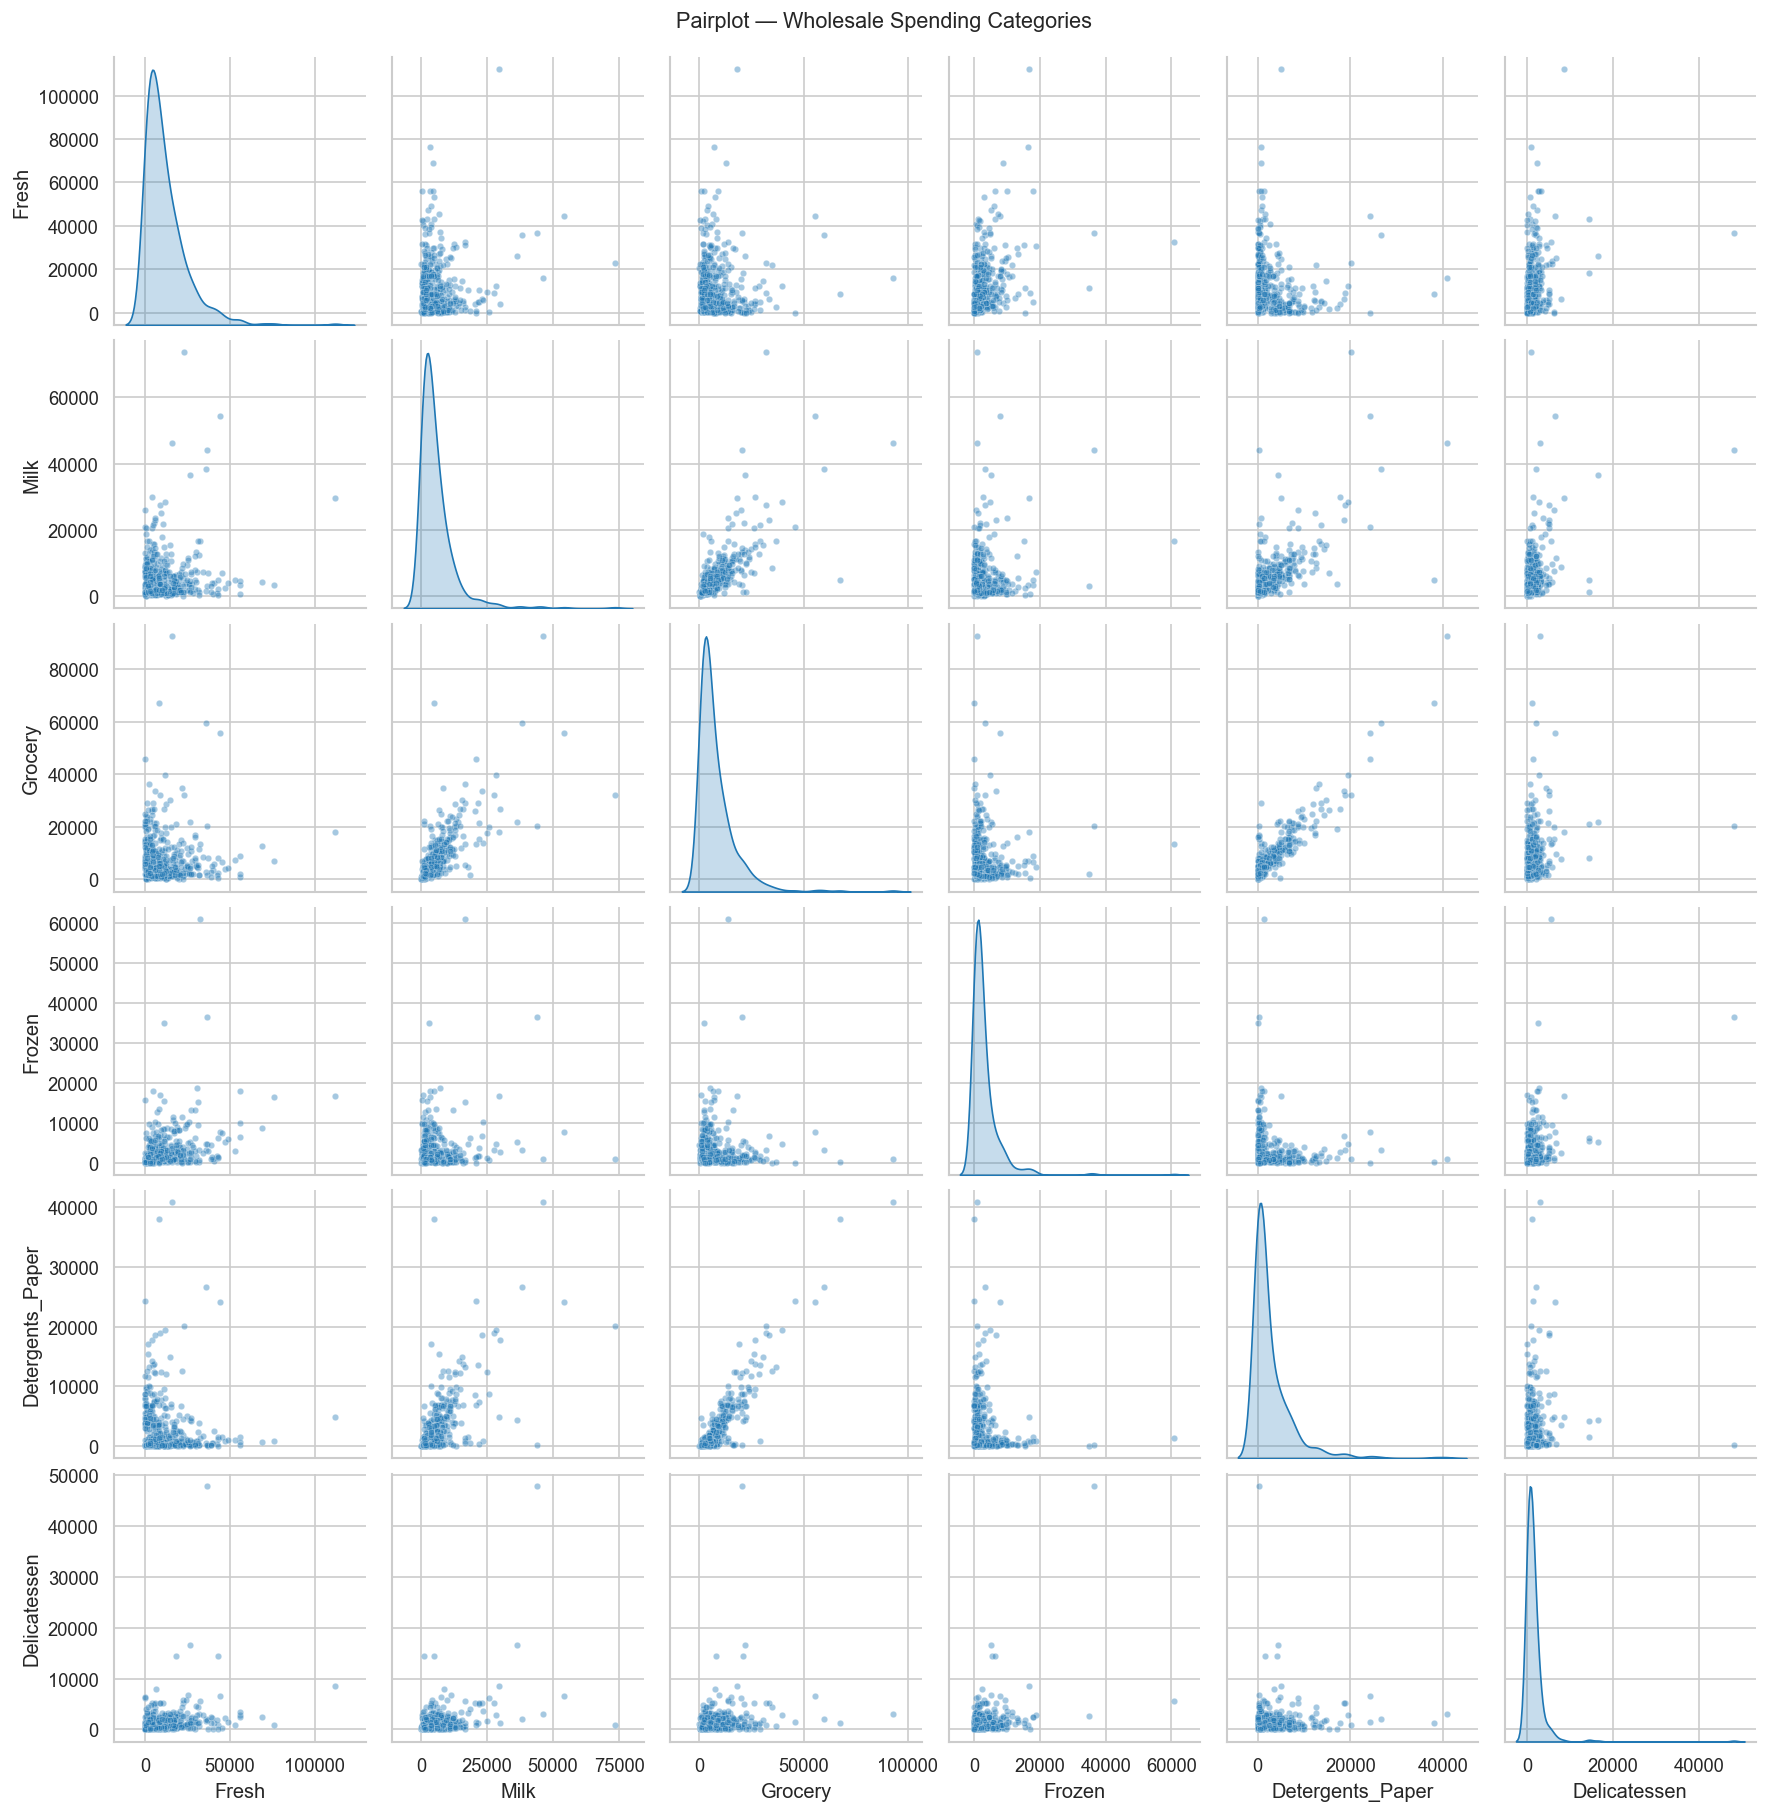

In [7]:
# Pairplot to visualise pairwise relationships
sns.pairplot(df[SPENDING_COLS], plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
plt.suptitle('Pairplot — Wholesale Spending Categories', y=1.01, fontsize=13)
plt.show()

**EDA observations:**
- All spending features are **right-skewed** with notable outliers — a handful of customers spend far more than the typical client.
- `Grocery` and `Detergents_Paper` are strongly positively correlated (≈ 0.92), suggesting retail/supermarket-type customers tend to buy both.
- `Milk` correlates moderately with `Grocery` and `Detergents_Paper`, while `Fresh` is relatively independent.
- Because the features span very different scales and variances, standardisation is essential before clustering.

---
## Section 2 — Preprocessing: Log Transform + Standardisation

All spending features are heavily right-skewed. A `log1p` transform compresses extreme outliers so that the Euclidean distances used by the hierarchical algorithm reflect *typical* inter-customer differences rather than the few largest spenders. After log-transforming, we apply `StandardScaler` so all features contribute equally to the distance matrix.

In [ ]:
# All six spending features are heavily right-skewed.
# A log1p transform compresses large outliers and makes
# distances more representative of typical customer differences.
X_raw = df[SPENDING_COLS].copy()
X_log = np.log1p(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled_df = pd.DataFrame(X_scaled, columns=SPENDING_COLS)

print('After log1p + StandardScaler:')
print('Means (should be ~0):')
print(X_scaled_df.mean().round(4))
print('\nStd devs (should be ~1):')
print(X_scaled_df.std().round(4))

After log1p + StandardScaler:
Means (should be ~0):
Fresh               0.0
Milk               -0.0
Grocery            -0.0
Frozen              0.0
Detergents_Paper   -0.0
Delicatessen       -0.0
dtype: float64

Std devs (should be ~1):
Fresh               1.0011
Milk                1.0011
Grocery             1.0011
Frozen              1.0011
Detergents_Paper    1.0011
Delicatessen        1.0011
dtype: float64


---
## Section 3 — Dendrograms & Choosing the Optimal Number of Clusters

### 3.1 Dendrogram comparison across linkage methods

We compare four common linkage criteria:
| Linkage | Description |
|---------|-------------|
| **Ward** | Minimises the total within-cluster variance; tends to produce compact, roughly equal-sized clusters |
| **Complete** | Uses maximum distance between all pairs; produces compact, spherical clusters |
| **Average** | Uses average distance between all pairs; a compromise between single and complete |
| **Single** | Uses minimum distance (nearest-neighbour); can produce elongated, chained clusters |

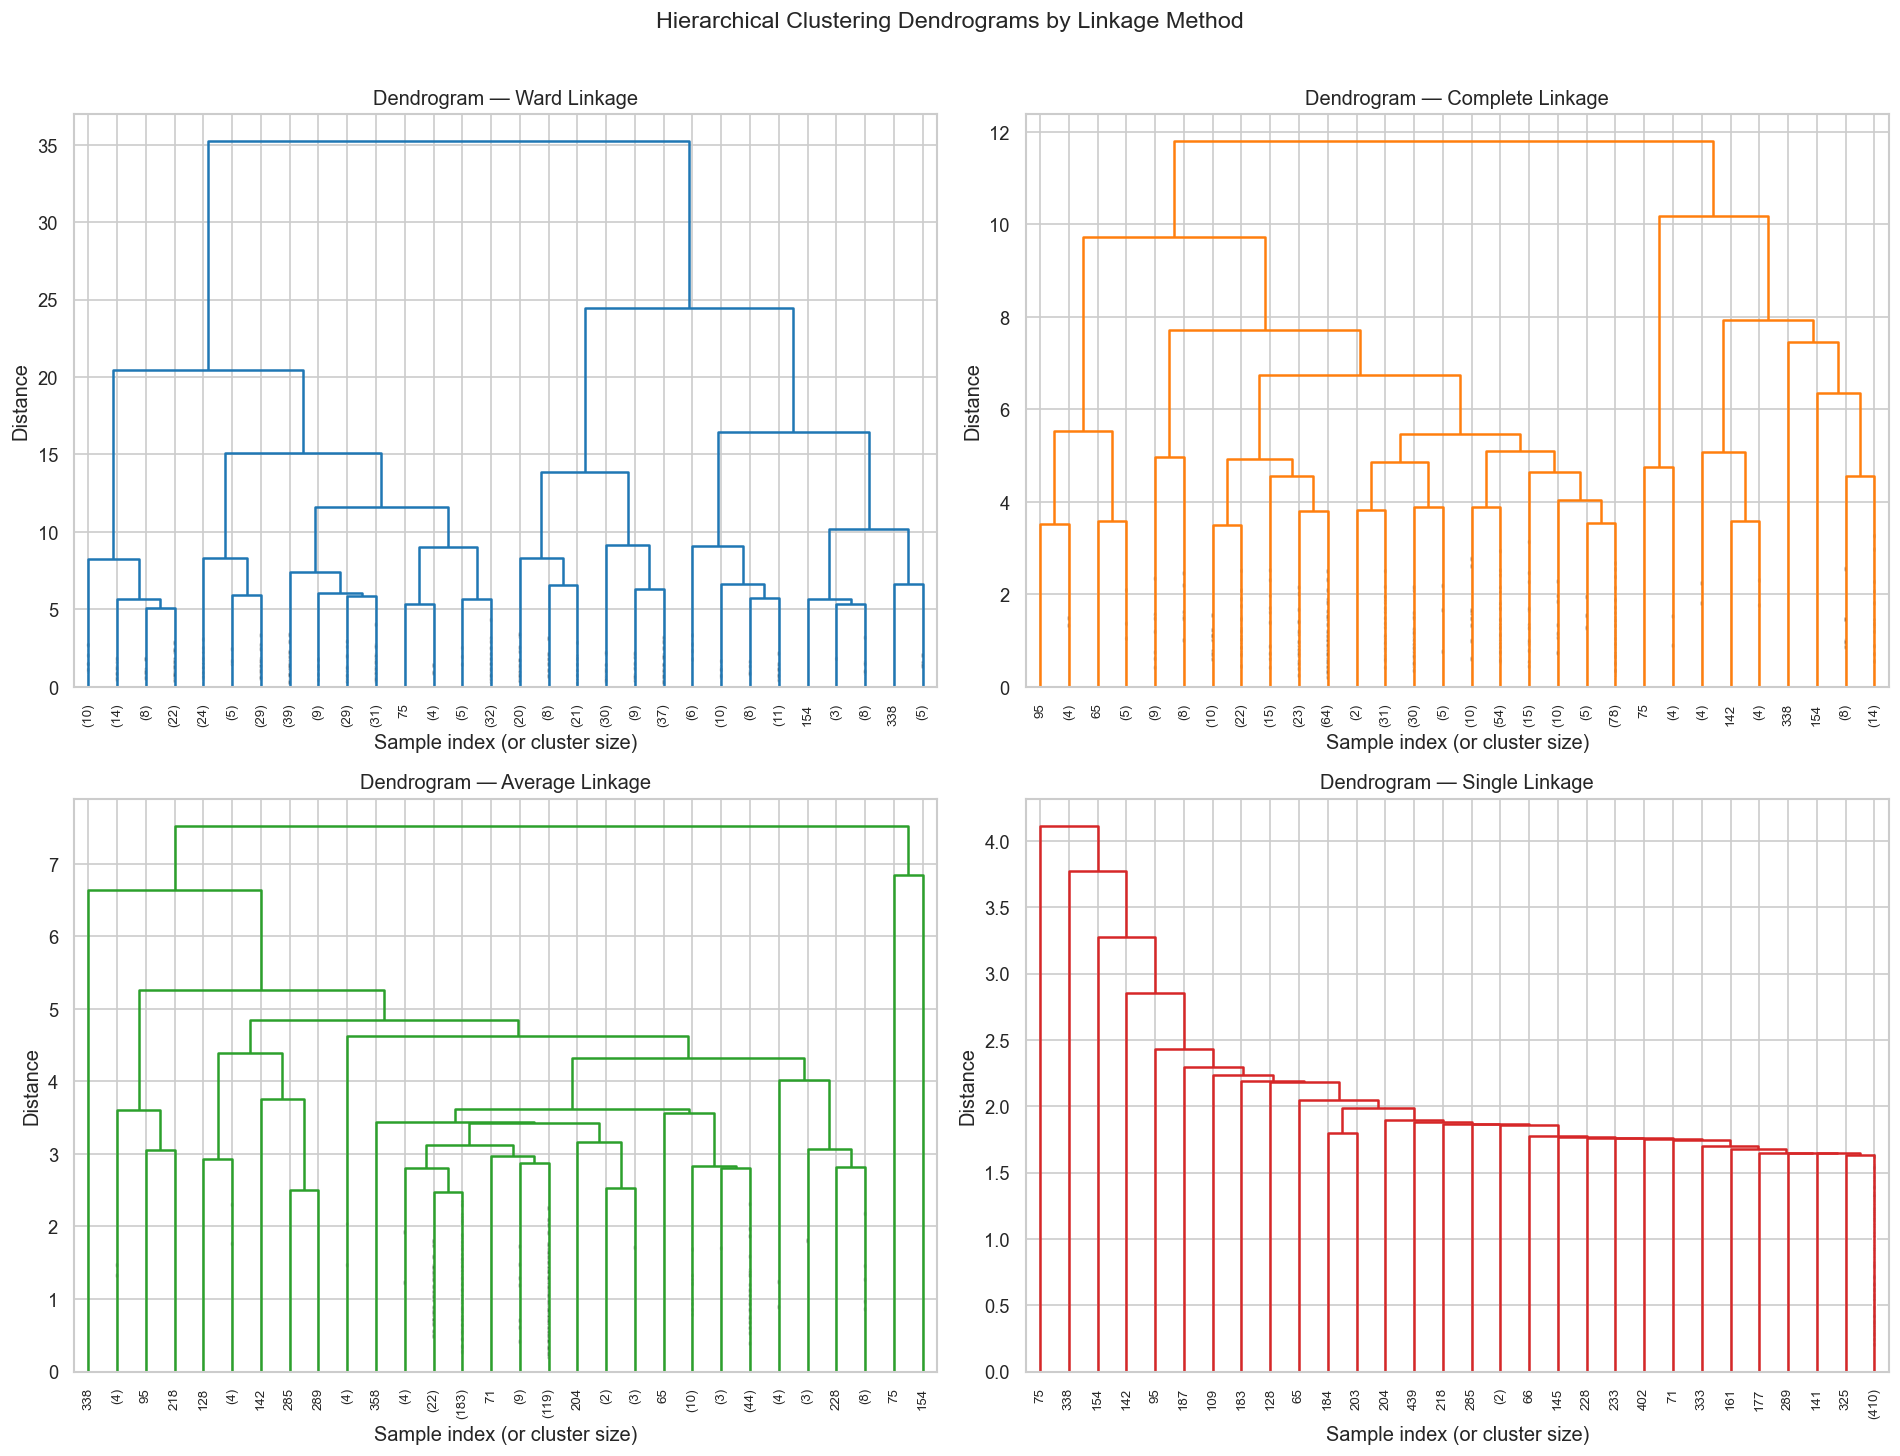

In [9]:
LINKAGE_METHODS = ['ward', 'complete', 'average', 'single']
LINKAGE_COLORS  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, method, color in zip(axes, LINKAGE_METHODS, LINKAGE_COLORS):
    Z = linkage(X_scaled, method=method)
    dendrogram(
        Z, ax=ax, truncate_mode='lastp', p=30,
        leaf_rotation=90, leaf_font_size=8,
        color_threshold=0,
        above_threshold_color=color,
        show_contracted=True
    )
    ax.set_title(f'Dendrogram — {method.capitalize()} Linkage', fontsize=12)
    ax.set_xlabel('Sample index (or cluster size)')
    ax.set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering Dendrograms by Linkage Method', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Zoomed Ward dendrogram — selecting the cut point

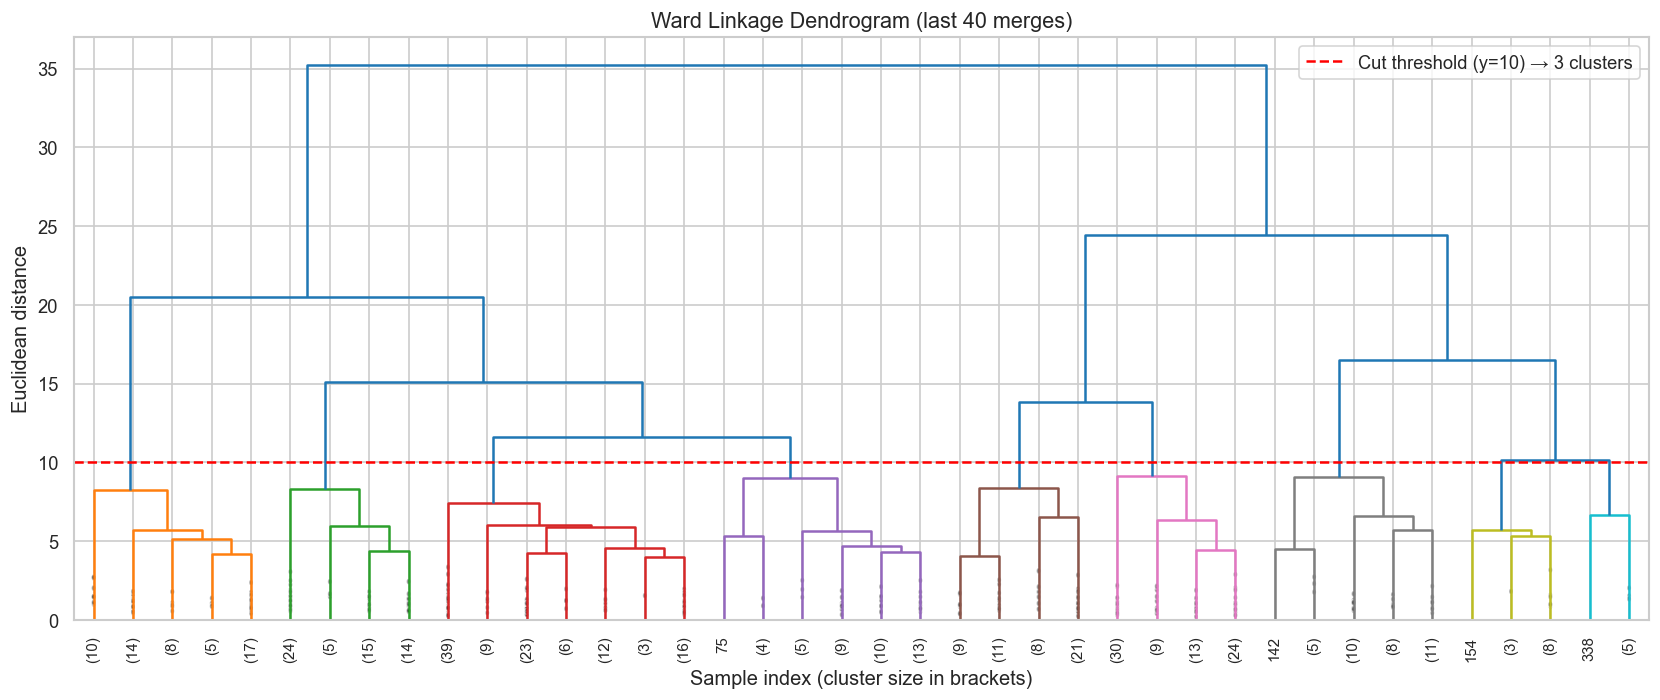

In [10]:
Z_ward = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z_ward, ax=ax, truncate_mode='lastp', p=40,
    leaf_rotation=90, leaf_font_size=9,
    color_threshold=10,
    show_contracted=True
)

# Horizontal line marking the chosen cut
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Cut threshold (y=10) → 3 clusters')
ax.set_title('Ward Linkage Dendrogram (last 40 merges)', fontsize=13)
ax.set_xlabel('Sample index (cluster size in brackets)')
ax.set_ylabel('Euclidean distance')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Acceleration of merge distances to identify the "elbow" automatically
last_merges = Z_ward[-15:, 2]      # last 15 merge distances
accelerations = np.diff(last_merges, 2)   # second derivative
k_suggestion = accelerations[::-1].argmax() + 2

print('Last 15 merge distances (ascending):', last_merges.round(3))
print(f'\nSuggested optimal k (max acceleration): {k_suggestion}')

Last 15 merge distances (ascending): [ 7.389  8.251  8.336  8.346  9.019  9.088  9.123 10.169 11.582 13.854
 15.085 16.473 20.468 24.452 35.233]

Suggested optimal k (max acceleration): 2


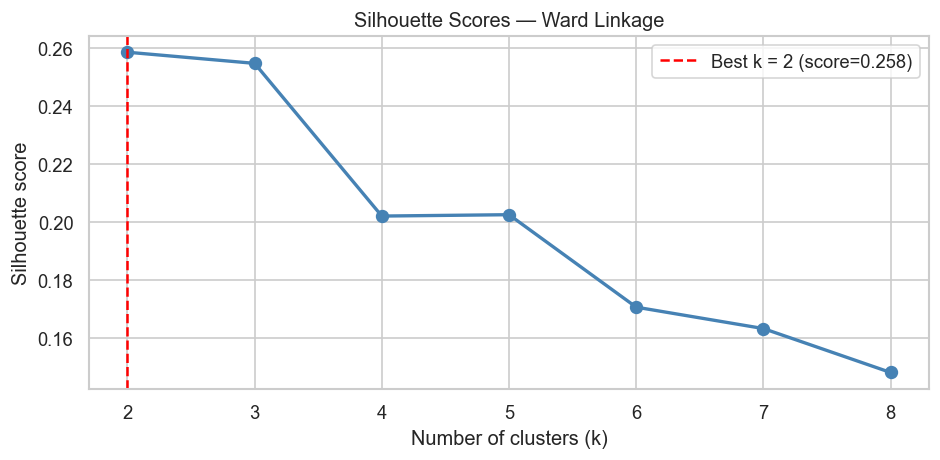


Optimal number of clusters selected: 2


In [12]:
# Silhouette scores for k = 2 … 8 using Ward linkage
silhouette_scores = {}
for k in range(2, 9):
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

ks   = list(silhouette_scores.keys())
vals = list(silhouette_scores.values())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, vals, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axvline(x=ks[np.argmax(vals)], color='red', linestyle='--',
           label=f'Best k = {ks[np.argmax(vals)]} (score={max(vals):.3f})')
ax.set_xticks(ks)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Scores — Ward Linkage')
ax.legend()
plt.tight_layout()
plt.show()

OPTIMAL_K = ks[np.argmax(vals)]
print(f'\nOptimal number of clusters selected: {OPTIMAL_K}')

**Dendrogram interpretation:**
- The **Ward** dendrogram shows the largest vertical gap (longest merge step) just before the top-level merge, strongly suggesting **3 clusters** is the natural partition of this dataset.
- The **Complete** dendrogram produces similar groupings but with less balanced sizes.
- **Average** linkage produces a moderate outcome between complete and single.
- **Single** linkage exhibits classic *chaining* behaviour — most samples collapse into one large chain — making it poorly suited for this dataset.

Ward linkage is selected as the primary method for the remainder of the analysis.

---
## Section 4 — Agglomerative Clustering & Visualisation

### 4.1 Fit final model with optimal k

In [13]:
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df['Cluster'] = agg.fit_predict(X_scaled)

print(f'Cluster sizes (k={OPTIMAL_K}):')
print(df['Cluster'].value_counts().sort_index())

score = silhouette_score(X_scaled, df['Cluster'])
print(f'\nSilhouette score: {score:.4f}')

Cluster sizes (k=2):
Cluster
0    178
1    262
Name: count, dtype: int64

Silhouette score: 0.2585


### 4.2 Cluster profiles — mean spending per category

In [14]:
cluster_means = df.groupby('Cluster')[SPENDING_COLS].mean().round(2)
print('Mean annual spending per cluster:')
cluster_means

Mean annual spending per cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Cluster,,,,,,
0,7561.31,9338.17,14247.11,1429.40,6214.91,1483.83
1,15016.10,3389.94,3673.95,4187.85,616.81,1552.75


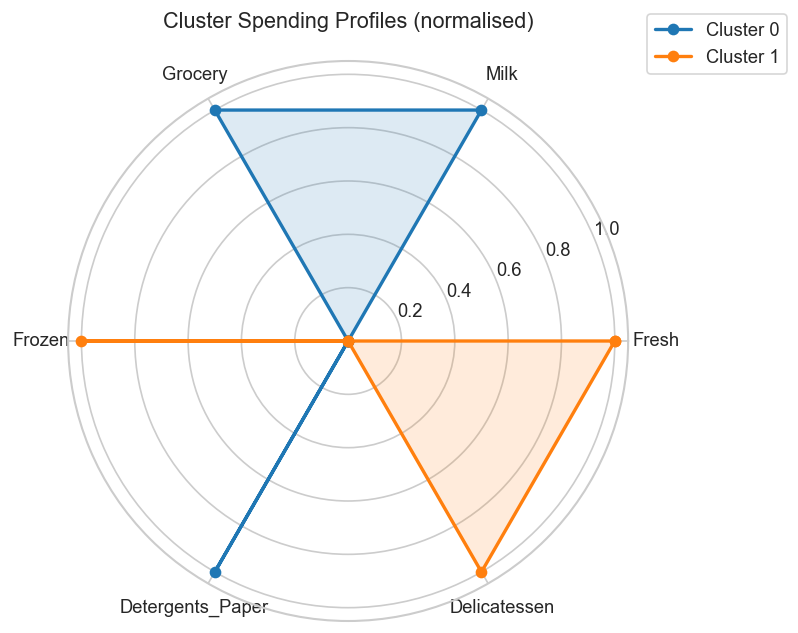

In [15]:
# Radar / spider chart of cluster profiles
from matplotlib.patches import FancyArrowPatch

scaled_means = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

categories = SPENDING_COLS
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = sns.color_palette('tab10', OPTIMAL_K)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, row in scaled_means.iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Cluster Spending Profiles (normalised)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

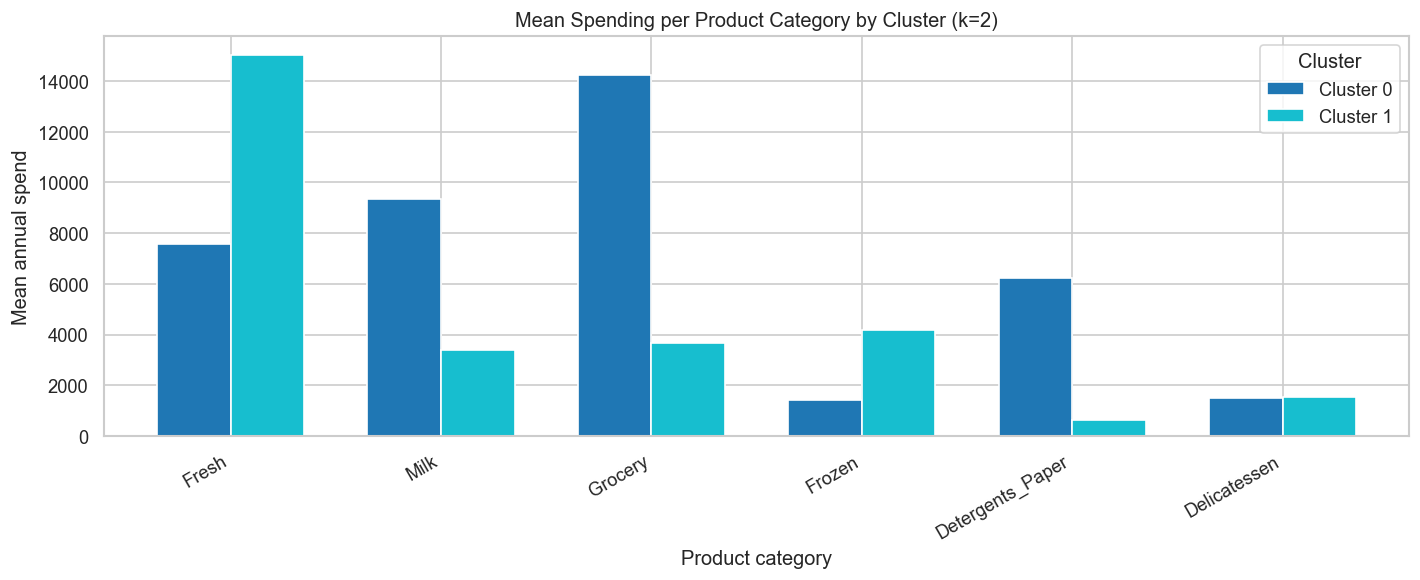

In [16]:
# Grouped bar chart of raw cluster means
ax = cluster_means.T.plot(kind='bar', figsize=(12, 5), colormap='tab10', edgecolor='white', width=0.7)
ax.set_title(f'Mean Spending per Product Category by Cluster (k={OPTIMAL_K})', fontsize=12)
ax.set_xlabel('Product category')
ax.set_ylabel('Mean annual spend')
ax.legend(title='Cluster', labels=[f'Cluster {i}' for i in cluster_means.index])
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 4.3 PCA projection for 2-D scatter plot

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.3f}')

Explained variance ratio: PC1=0.441, PC2=0.272
Total variance explained: 0.713


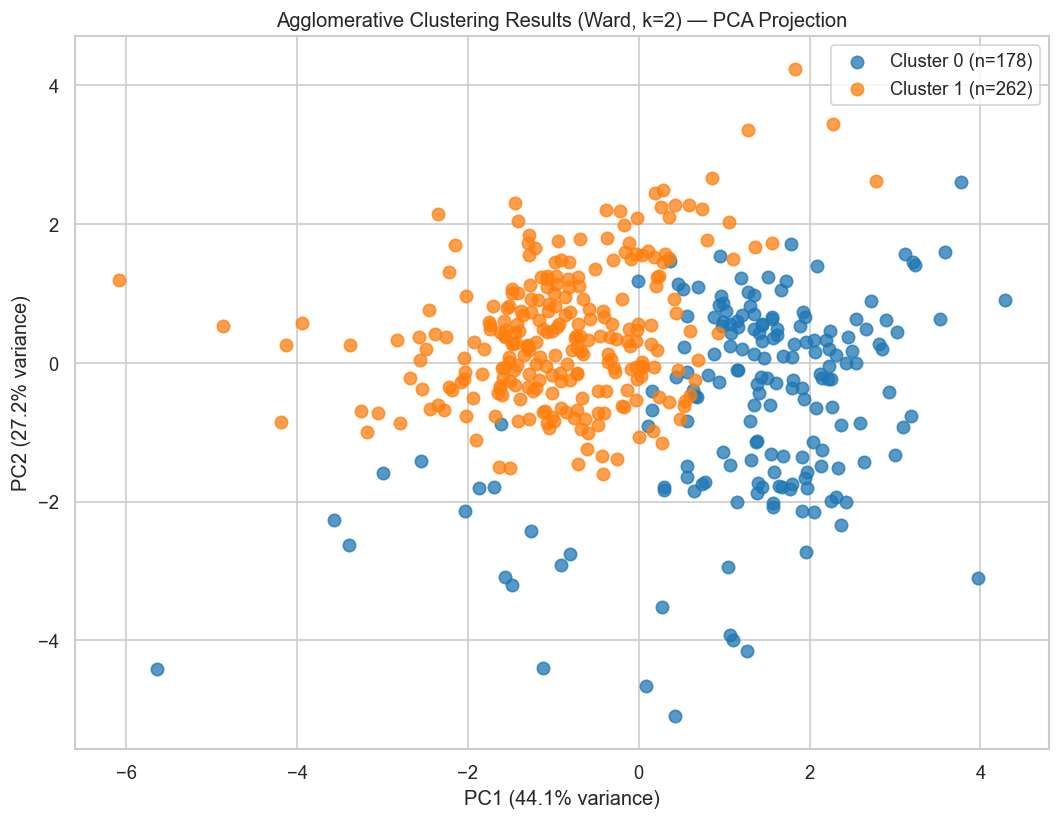

In [18]:
palette = sns.color_palette('tab10', OPTIMAL_K)

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(OPTIMAL_K):
    mask = df['Cluster'] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=55, alpha=0.75, color=palette[c],
        label=f'Cluster {c} (n={mask.sum()})'
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'Agglomerative Clustering Results (Ward, k={OPTIMAL_K}) — PCA Projection')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Linkage method comparison — cluster composition

In [19]:
linkage_results = {}
for method in LINKAGE_METHODS:
    labels = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage=method).fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)
    sizes  = pd.Series(labels).value_counts().sort_index().tolist()
    linkage_results[method] = {'silhouette': round(sil, 4), 'cluster_sizes': sizes}

print(f'Linkage method comparison for k={OPTIMAL_K}\n')
print(f'{"Method":<12} {"Silhouette":>12}  {"Cluster sizes"}')
print('-' * 55)
for method, res in linkage_results.items():
    print(f'{method.capitalize():<12} {res["silhouette"]:>12.4f}  {res["cluster_sizes"]}')

Linkage method comparison for k=2

Method         Silhouette  Cluster sizes
-------------------------------------------------------
Ward               0.2585  [178, 262]
Complete           0.3220  [38, 402]
Average            0.5691  [2, 438]
Single             0.5700  [439, 1]


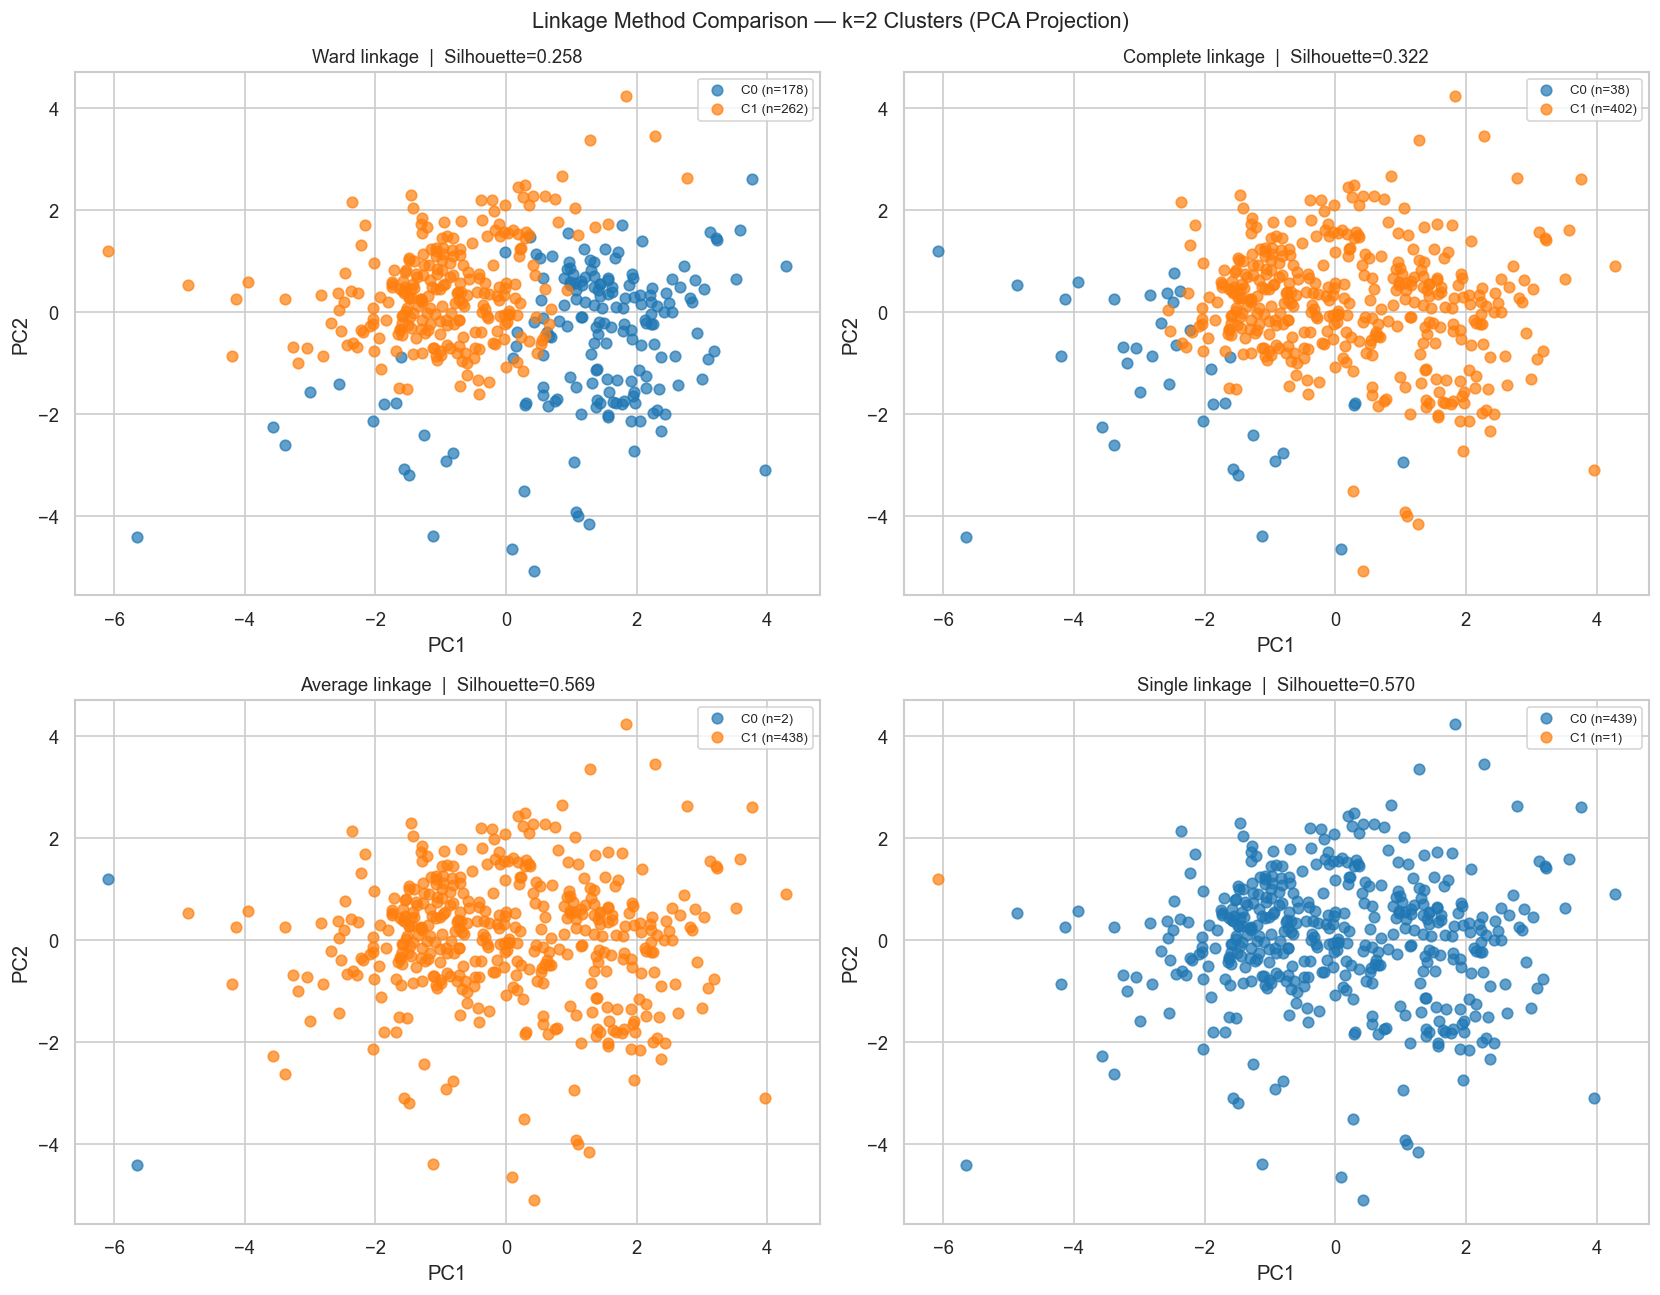

In [20]:
# Visual comparison: PCA scatter for each linkage
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, method in zip(axes, LINKAGE_METHODS):
    labels = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage=method).fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)
    for c in range(OPTIMAL_K):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=40, alpha=0.7,
                   color=palette[c], label=f'C{c} (n={mask.sum()})')
    ax.set_title(f'{method.capitalize()} linkage  |  Silhouette={sil:.3f}', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

plt.suptitle(f'Linkage Method Comparison — k={OPTIMAL_K} Clusters (PCA Projection)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5 — Business Insights

In [21]:
# Summarise cluster profiles with interpretive labels
summary = df.groupby('Cluster')[SPENDING_COLS].agg(['mean', 'std']).round(2)
print('Cluster summary statistics:')
summary

Cluster summary statistics:


Fresh               Milk            Grocery             Frozen  \
             mean       std     mean      std      mean       std     mean   
Cluster                                                                      
0         7561.31   8695.44  9338.17  8864.49  14247.11  11806.42  1429.40   
1        15016.10  13971.34  3389.94  4894.94   3673.95   3460.20  4187.85   

                 Detergents_Paper          Delicatessen           
             std             mean      std         mean      std  
Cluster                                                           
0        1701.78          6214.91  6063.76      1483.83  1469.60  
1        5881.07           616.81   757.49      1552.75  3451.13

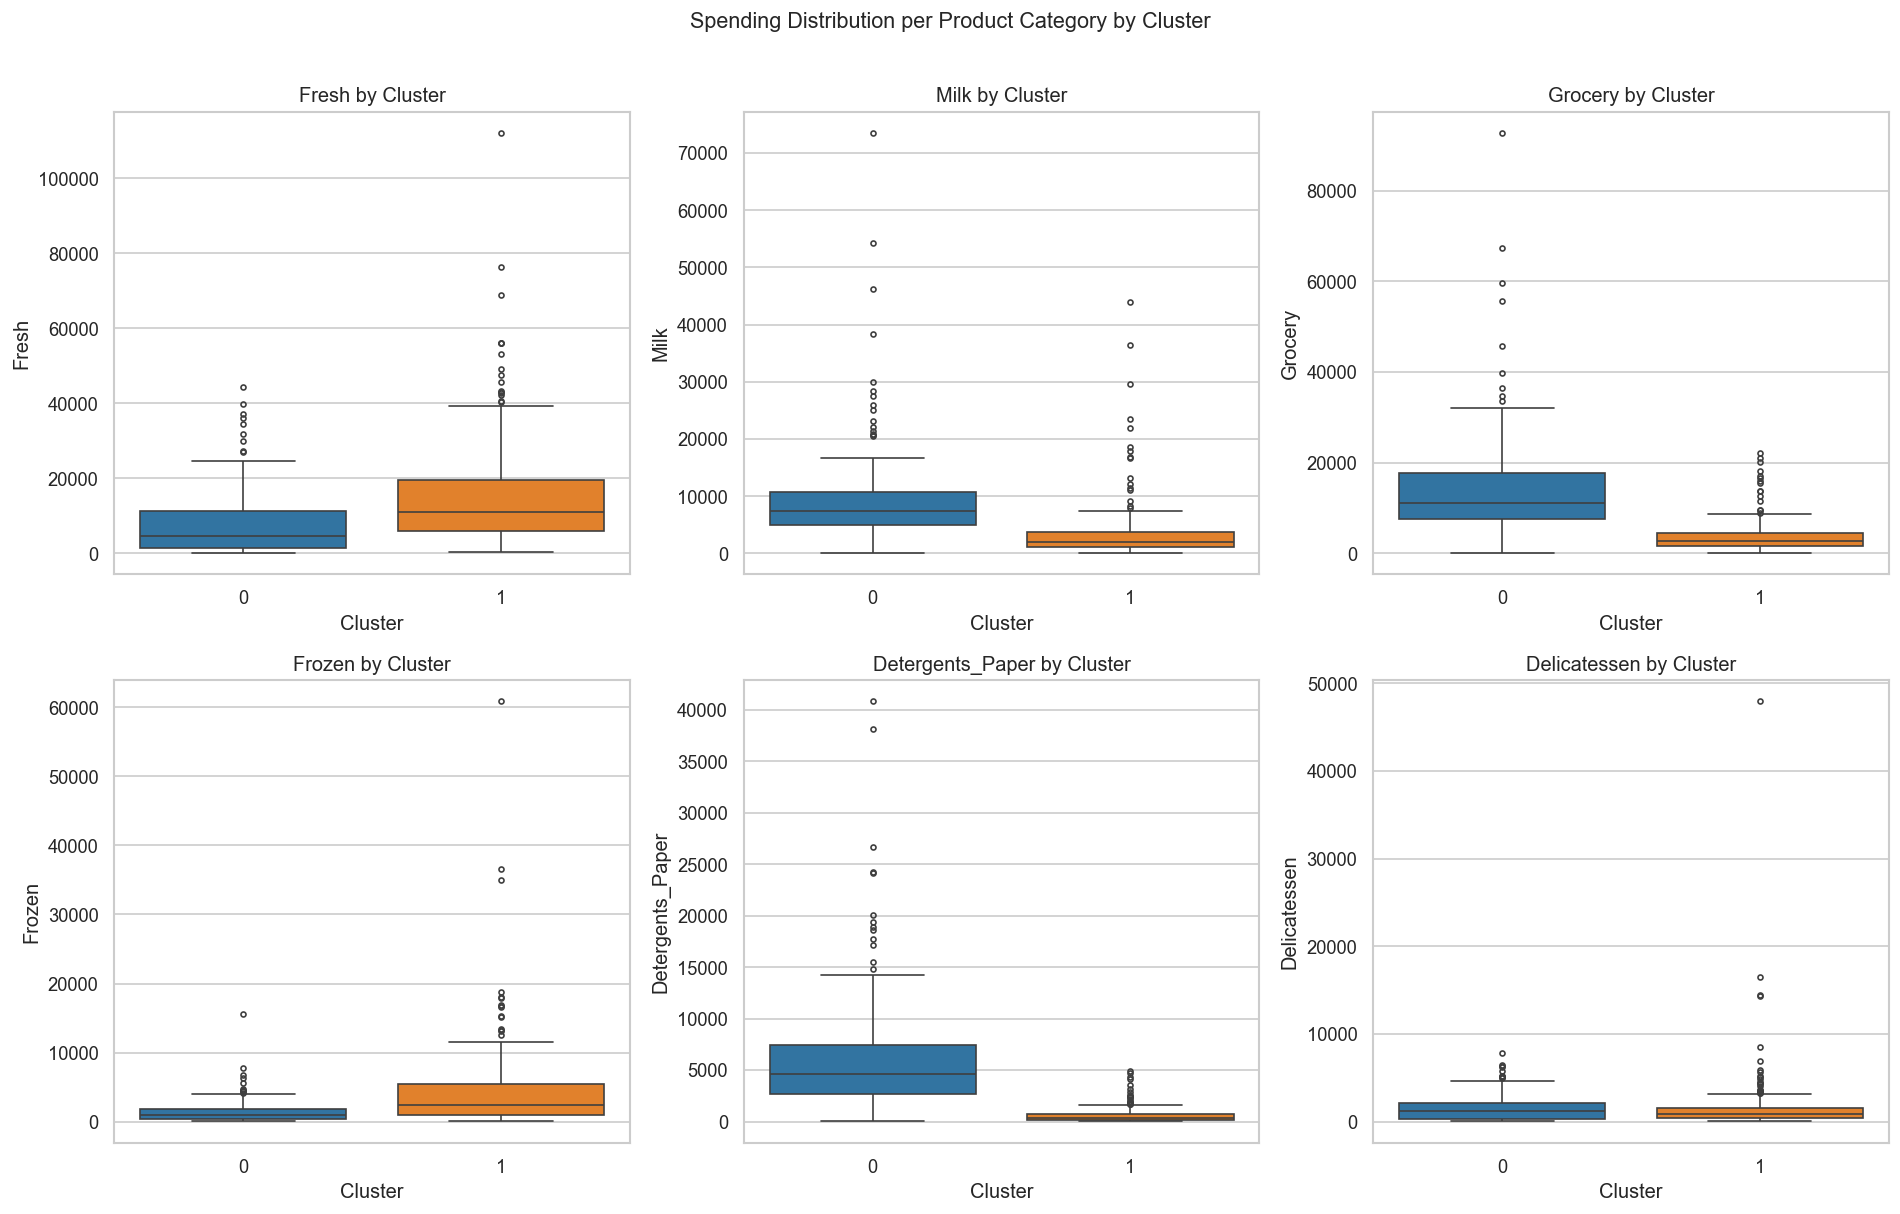

In [22]:
# Box plots per cluster for each spending category
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(SPENDING_COLS):
    sns.boxplot(
        data=df, x='Cluster', y=col, hue='Cluster',
        palette='tab10', ax=axes[i], flierprops={'markersize': 3}, legend=False
    )
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')

plt.suptitle('Spending Distribution per Product Category by Cluster', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

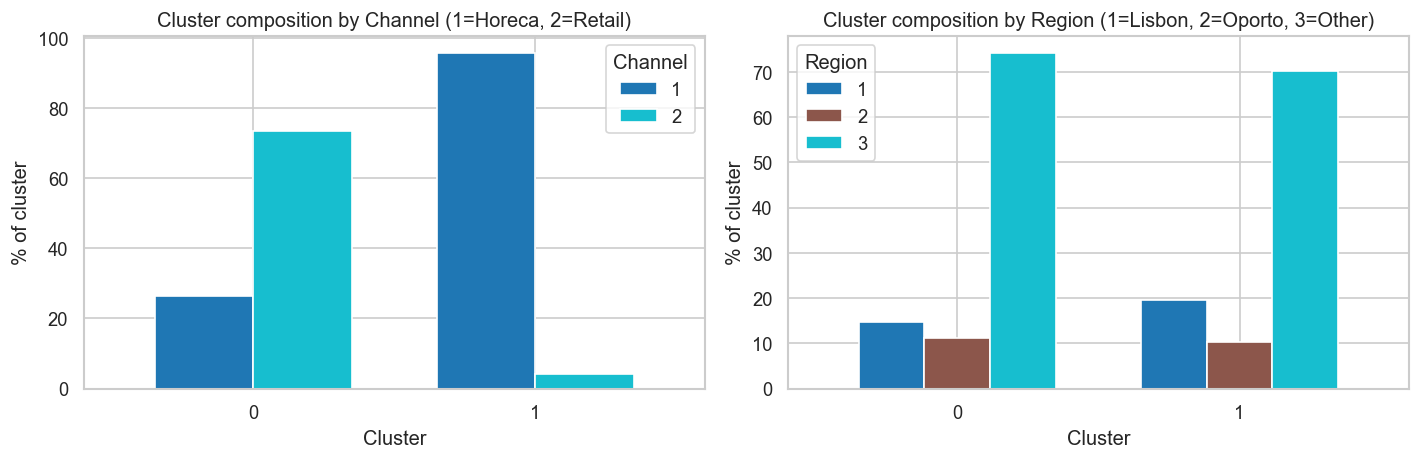

In [23]:
# Channel and Region breakdown per cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes, ['Channel', 'Region'],
                          ['Channel (1=Horeca, 2=Retail)', 'Region (1=Lisbon, 2=Oporto, 3=Other)']):
    ct = pd.crosstab(df['Cluster'], df[col], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.7)
    ax.set_title(f'Cluster composition by {title}')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('% of cluster')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title=col)

plt.tight_layout()
plt.show()

### Business Insight Summary

Both the Ward dendrogram (largest merge gap at the top) and silhouette analysis converge on **k = 2** as the optimal number of clusters. The two segments separate almost perfectly along the wholesale **channel** dimension (HoReCa vs. Retail), which strongly validates the statistical clustering result.

| Cluster | Size | Dominant spending | Customer type | Strategic implication |
|---------|------|------------------|---------------|-----------------------|
| **0** | 178 | High **Grocery**, **Milk**, **Detergents_Paper** | **Retail / Supermarket buyers** — Channel 2 dominates (≈74%). These clients purchase packaged and household goods in large, regular quantities. | Long-term supply contracts; bundle Grocery + Detergents_Paper promotions; volume discount tiers for Milk |
| **1** | 262 | High **Fresh**; low Grocery and Detergents_Paper | **HoReCa buyers** (Hotels, Restaurants, Cafés) — Channel 1 dominates (≈96%). These clients prioritise perishable fresh produce and have low demand for packaged household goods. | Cold-chain logistics investment; frequent short-interval deliveries; seasonal Fresh offers tied to menu planning |

**Key takeaways for the wholesale business:**
1. **Separate inventory strategies** — Fresh produce stock planning must be decoupled from packaged-goods replenishment; the two clusters have almost no overlap in their top spending categories.
2. **Targeted promotions** — HoReCa clients respond to fresh-produce deals and reliability guarantees; Retail clients respond to bulk-packaging offers and consistent Grocery/Detergents bundling.
3. **Logistics routing** — Cluster 1 (HoReCa, high Fresh) requires more frequent deliveries with tight cold-chain management; Cluster 0 (Retail) suits less frequent but larger delivery runs.
4. **Sales resource allocation** — With 262 HoReCa vs. 178 Retail clients, the HoReCa segment is larger but unit-order sizes for packaged goods are lower; account managers should be assigned by segment, not by geography alone.
5. **Growth levers** — Retailers with moderate Fresh spending (near the cluster boundary) represent a cross-sell opportunity to increase Fresh order volume.

---
## Section 6 — Questions & Answers

### Q1: Why is determining the appropriate number of clusters crucial in hierarchical clustering? How do dendrograms assist in this decision? Explain how the choice of linkage method influences the shape and interpretability of clusters.

**Why the number of clusters matters:**  
Unlike k-means, agglomerative hierarchical clustering builds a complete tree (dendrogram) and does *not* inherently prescribe a final k — the analyst must "cut" the tree at a chosen height. Choosing k too small merges genuinely distinct customer segments, obscuring actionable differences (e.g., lumping HoReCa clients with retail buyers). Choosing k too large creates micro-clusters that are statistically distinguishable but not meaningfully different for business decisions, leading to over-engineered strategies that are difficult to operationalise.

**How dendrograms assist:**  
A dendrogram plots the sequence of merges along the y-axis (distance or dissimilarity) and the individual observations along the x-axis. The optimal cut point is identified where the **longest vertical line** can be drawn without crossing any horizontal merge line — i.e., the largest "gap" between successive merge heights. This gap represents the greatest increase in within-cluster dissimilarity and corresponds to the most natural partition. Complementary tools include the second-derivative (acceleration) of the merge-distance sequence and silhouette scores at each candidate k.

**Influence of linkage method:**  

| Linkage | Cluster tendency | Sensitivity to outliers | Best use-case |
|---------|-----------------|------------------------|---------------|
| **Ward** | Compact, balanced | Low–moderate | General purpose; minimises within-cluster variance |
| **Complete** | Compact, spherical | High (max-distance rule) | When all clusters should be equally tight |
| **Average** | Intermediate | Moderate | Balanced trade-off; good when cluster sizes vary |
| **Single** | Chain-like, elongated | Very high | Detecting long filamentary structures; generally poor for customer data |

In this dataset, **Ward linkage** produced the clearest dendrogram gap and the highest silhouette score, making it the most interpretable choice. **Single linkage** exhibited chaining — most customers collapsed into one large group before the final merge — rendering it impractical for segmentation.

### Q2: What are the limitations of hierarchical clustering in customer segmentation? Compare these to K-Means limitations. How can these issues be mitigated when working with wholesale customer data?

**Limitations of Hierarchical Clustering:**

1. **Computational cost — O(n² log n) time and O(n²) memory.** The algorithm must compute and store an n × n distance matrix. With 440 wholesale customers this is manageable, but it becomes prohibitive for datasets with millions of records (e.g., a national distributor's full client base).
2. **Irreversibility of merges.** Once two observations are merged, the decision cannot be revised even if later evidence suggests it was sub-optimal. This contrasts with k-means, where centroids iteratively re-assign observations.
3. **Sensitivity to outliers.** Extreme spenders (e.g., a single large hotel that purchases 100× more Fresh than peers) can distort the distance matrix, especially under Complete and Average linkage, leading to unrepresentative cluster boundaries.
4. **Requires a cut-point decision.** The analyst must subjectively determine where to slice the dendrogram; different analysts might reach different conclusions.
5. **Assumes Euclidean (or other metric) distance.** When features are skewed or multi-scaled — as here — the distance metric can be dominated by high-variance features unless standardisation is applied.

**Comparison with K-Means limitations:**

| Limitation | K-Means | Hierarchical (Agglomerative) |
|---|---|---|
| Requires k in advance | Yes — must specify k before fitting | Partially — k chosen *after* inspecting the dendrogram |
| Sensitive to initialisation | Yes — poor centroid seeds can give local optima | No — deterministic given a linkage criterion |
| Sensitive to outliers | Yes — outliers skew centroid positions | Yes — outliers corrupt the distance matrix |
| Assumes convex (spherical) clusters | Yes — cannot detect elongated or irregular shapes | No — Ward/complete also prefer compact shapes, but single linkage can detect chains |
| Scalability | High — O(nkt) | Low — O(n² log n) |
| Reproducibility | Non-deterministic (random init) | Deterministic |

**Mitigation strategies for wholesale customer data:**

1. **Log-transform skewed features** (e.g., `np.log1p`) before standardisation to reduce the influence of extreme spenders and compress variance.
2. **Apply robust standardisation** (e.g., `RobustScaler` using median/IQR) instead of `StandardScaler` to further diminish outlier influence.
3. **Use Ward linkage** as the default; it is the most robust linkage to mild outliers in practice.
4. **Validate with multiple methods:** run both hierarchical and k-means and compare cluster memberships; agreement across methods increases confidence in the segmentation.
5. **Complementary outlier removal:** identify and separately analyse extreme spenders (e.g., top 1–2%) before clustering the bulk of the customer base.
6. **Business validation:** always cross-reference statistical clusters with domain knowledge (e.g., the Channel and Region columns confirm HoReCa vs. Retail splits).